# Task 4 — Advanced Analytics (Basic)
**ApexPlanet Data Analytics Internship**  
**Dataset:** E-commerce Sales (Cleaned)  
**Timeline:** 6 Days (Day 21–26)

---

## 📋 What We Cover
| Days | Topic |
|------|-------|
| Day 21–22 | Statistical Analysis (Descriptive + Hypothesis Testing) |
| Day 23–24 | Customer Segmentation using K-Means Clustering |
| Day 25–26 | Basic Predictive Model (Linear + Logistic Regression) |

---

## 📦 Step 1: Import Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Statistical libraries
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency, norm

# Machine learning libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📂 Step 2: Load Cleaned Dataset

In [27]:
df = pd.read_csv('../data/data_cleaned.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f'✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Date range: {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()}')
df.head(3)

✅ Dataset loaded: 333,234 rows × 12 columns
Date range: 2010-12-01 → 2011-12-09


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,Day,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010,12,1,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010,12,1,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010,12,1,22.00


---
# 📅 DAY 21–22: STATISTICAL ANALYSIS

## 📊 Part A — Descriptive Statistics

In [28]:
# Basic descriptive statistics
print('=== Descriptive Statistics ===')
display(df[['Quantity', 'UnitPrice', 'TotalPrice']].describe().round(2))

=== Descriptive Statistics ===


,Quantity,UnitPrice,TotalPrice
count,333234.00,333234.00,333234.00
mean,7.55,2.19,12.90
std,6.78,1.55,13.21
min,1.00,0.00,0.00
25%,2.00,1.25,3.90
50%,6.00,1.65,10.14
75%,12.00,2.95,17.40
max,27.00,7.50,178.80


In [29]:
# Skewness and Kurtosis
print('=== Skewness (how lopsided the data is) ===')
print(df[['Quantity', 'UnitPrice', 'TotalPrice']].skew().round(2))

print('\n=== Kurtosis (how heavy the tails are) ===')
print(df[['Quantity', 'UnitPrice', 'TotalPrice']].kurtosis().round(2))

print('\n📌 Interpretation:')
print('   Skewness > 0 → Right skewed (most values are low, a few are very high)')
print('   Kurtosis > 3 → Heavy tails (many extreme values)')

=== Skewness (how lopsided the data is) ===
Quantity      1.19
UnitPrice     1.09
TotalPrice    3.25
dtype: float64

=== Kurtosis (how heavy the tails are) ===
Quantity       0.62
UnitPrice      0.59
TotalPrice    18.11
dtype: float64

📌 Interpretation:
   Skewness > 0 → Right skewed (most values are low, a few are very high)
   Kurtosis > 3 → Heavy tails (many extreme values)


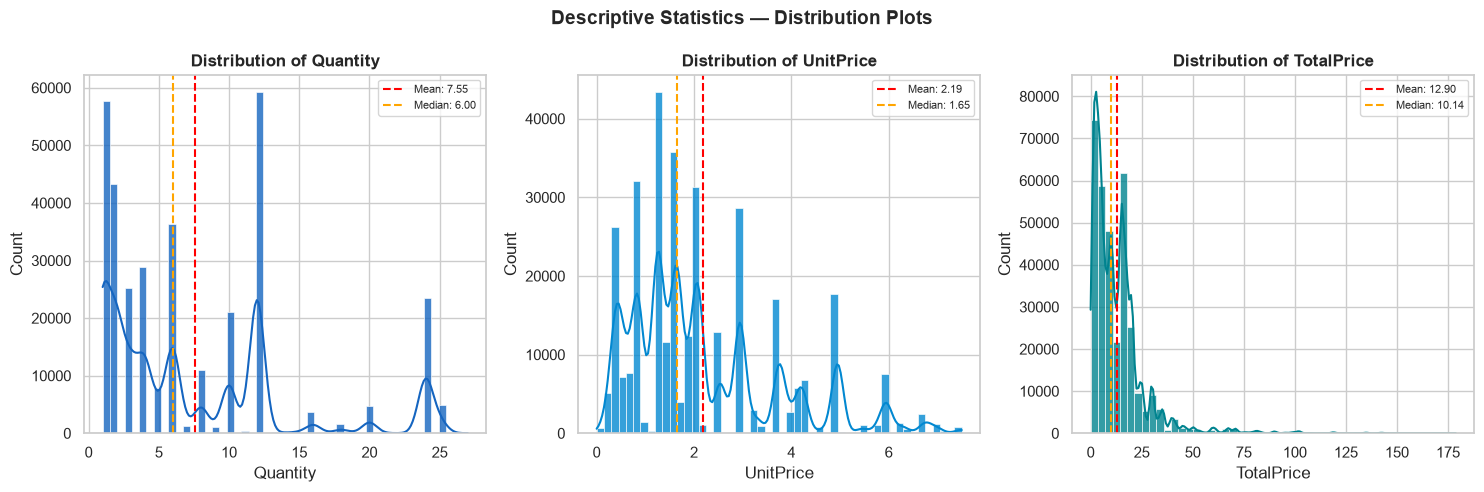

✅ Saved: reports/stat_distributions.png


In [30]:
# Visual summary — distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cols = ['Quantity', 'UnitPrice', 'TotalPrice']
colors = ['#1565C0', '#0288D1', '#00838F']

for ax, col, color in zip(axes, cols, colors):
    sns.histplot(df[col], bins=50, ax=ax, color=color, kde=True, alpha=0.8)
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='orange', linestyle='--', label=f'Median: {df[col].median():.2f}')
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Descriptive Statistics — Distribution Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/stat_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: reports/stat_distributions.png')

## 🧪 Part B — Hypothesis Testing

### 🔬 Test 1 — T-Test: UK vs Non-UK Spending
**Question:** Do UK customers spend more per transaction than non-UK customers?

In [31]:
uk     = df[df['Country'] == 'United Kingdom']['TotalPrice']
non_uk = df[df['Country'] != 'United Kingdom']['TotalPrice']

t_stat, p_value = ttest_ind(uk, non_uk)

print('=' * 55)
print('   T-TEST: UK vs Non-UK Customer Spending')
print('=' * 55)
print(f'  UK Average Spend     : £{uk.mean():.2f}')
print(f'  Non-UK Average Spend : £{non_uk.mean():.2f}')
print(f'  T-Statistic          : {t_stat:.4f}')
print(f'  P-Value              : {p_value:.6f}')
print(f'  Significance Level   : 0.05')

if p_value < 0.05:
    print('\n  ✅ RESULT: Significant difference exists (p < 0.05)')
    print('  📌 Business Insight: Spending behavior differs significantly')
    print('     between UK and non-UK customers.')
else:
    print('\n  ❌ RESULT: No significant difference found (p >= 0.05)')
print('=' * 55)

   T-TEST: UK vs Non-UK Customer Spending
  UK Average Spend     : £12.26
  Non-UK Average Spend : £18.77
  T-Statistic          : -85.8256
  P-Value              : 0.000000
  Significance Level   : 0.05

  ✅ RESULT: Significant difference exists (p < 0.05)
  📌 Business Insight: Spending behavior differs significantly
     between UK and non-UK customers.


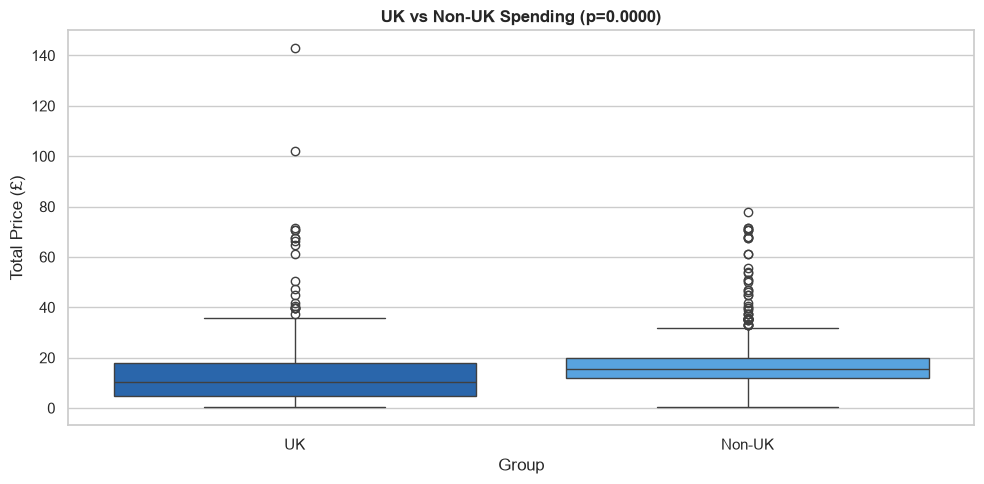

✅ Saved: reports/stat_ttest.png


In [32]:
# Visualize T-Test
fig, ax = plt.subplots(figsize=(10, 5))
data_plot = pd.DataFrame({
    'TotalPrice': pd.concat([uk.sample(500, random_state=42),
                             non_uk.sample(500, random_state=42)]),
    'Group': ['UK'] * 500 + ['Non-UK'] * 500
})
sns.boxplot(data=data_plot, x='Group', y='TotalPrice',
            palette=['#1565C0', '#42A5F5'], ax=ax)
ax.set_title(f'UK vs Non-UK Spending (p={p_value:.4f})', fontweight='bold')
ax.set_ylabel('Total Price (£)')
plt.tight_layout()
plt.savefig('../reports/stat_ttest.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: reports/stat_ttest.png')

### 🔬 Test 2 — Chi-Square Test: Month vs High-Value Orders
**Question:** Is there a relationship between the month and whether an order is high-value?

In [33]:
df['HighValue'] = (df['TotalPrice'] > df['TotalPrice'].median()).astype(int)
contingency     = pd.crosstab(df['Month'], df['HighValue'])

chi2, p, dof, expected = chi2_contingency(contingency)

print('=' * 55)
print('   CHI-SQUARE TEST: Month vs High-Value Orders')
print('=' * 55)
print(f'  Chi2 Statistic     : {chi2:.4f}')
print(f'  P-Value            : {p:.6f}')
print(f'  Degrees of Freedom : {dof}')

if p < 0.05:
    print('\n  ✅ RESULT: Month significantly affects order value (p < 0.05)')
    print('  📌 Business Insight: Certain months produce more high-value')
    print('     orders — use this for seasonal marketing planning.')
else:
    print('\n  ❌ RESULT: No significant relationship found (p >= 0.05)')
print('=' * 55)

   CHI-SQUARE TEST: Month vs High-Value Orders
  Chi2 Statistic     : 3022.4791
  P-Value            : 0.000000
  Degrees of Freedom : 11

  ✅ RESULT: Month significantly affects order value (p < 0.05)
  📌 Business Insight: Certain months produce more high-value
     orders — use this for seasonal marketing planning.


### 🔬 Test 3 — Confidence Intervals for Average Order Value

In [34]:
sample_data = df['TotalPrice'].sample(1000, random_state=42)
mean   = sample_data.mean()
se     = stats.sem(sample_data)
ci     = stats.t.interval(0.95, len(sample_data)-1, loc=mean, scale=se)

print('=' * 55)
print('   95% CONFIDENCE INTERVAL — Avg Order Value')
print('=' * 55)
print(f'  Sample Mean   : £{mean:.2f}')
print(f'  Std Error     : £{se:.2f}')
print(f'  95% CI Lower  : £{ci[0]:.2f}')
print(f'  95% CI Upper  : £{ci[1]:.2f}')
print(f'\n  📌 Business Insight:')
print(f'     We are 95% confident the true average order')
print(f'     value lies between £{ci[0]:.2f} and £{ci[1]:.2f}')
print('=' * 55)

   95% CONFIDENCE INTERVAL — Avg Order Value
  Sample Mean   : £13.30
  Std Error     : £0.41
  95% CI Lower  : £12.49
  95% CI Upper  : £14.11

  📌 Business Insight:
     We are 95% confident the true average order
     value lies between £12.49 and £14.11


---
# 📅 DAY 23–24: CUSTOMER SEGMENTATION (K-MEANS CLUSTERING)

### What is K-Means Clustering?
K-Means automatically groups customers into **K segments** based on their behavior. Think of it like sorting customers into buckets — Python figures out which bucket each customer belongs to!

In [35]:
# Build RFM features per customer
# R = Recency (how recently they bought)
# F = Frequency (how often they buy)
# M = Monetary (how much they spend)

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate',  lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',    'nunique'),
    Monetary  = ('TotalPrice',   'sum')
).reset_index()

print(f'✅ RFM table created: {rfm.shape[0]:,} customers')
print('\nRFM Summary:')
display(rfm.describe().round(2))

✅ RFM table created: 4,191 customers

RFM Summary:


,CustomerID,Recency,Frequency,Monetary
count,4191.00,4191.00,4191.00,4191.00
mean,15290.90,92.49,4.01,1025.88
std,1719.06,99.91,7.02,2200.19
min,12347.00,1.00,1.00,1.90
25%,13809.50,18.00,1.00,206.16
50%,15281.00,51.00,2.00,465.97
75%,16770.50,144.00,4.00,1127.34
max,18287.00,374.00,196.00,84980.89


In [36]:
# Scale the features
scaler  = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

print('✅ Features scaled using StandardScaler')
print(f'   Shape: {rfm_scaled.shape}')

✅ Features scaled using StandardScaler
   Shape: (4191, 3)


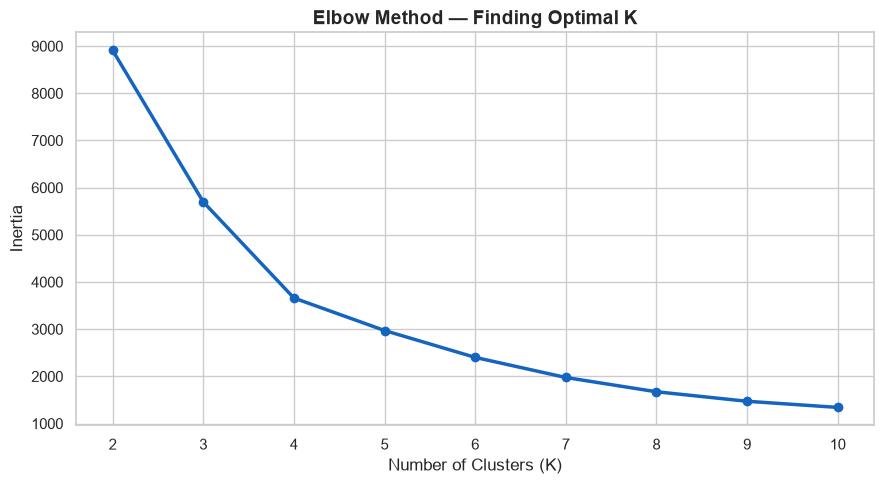

✅ Saved: reports/cluster_elbow.png

📌 Look at the chart — the "elbow" (sharpest bend) is your optimal K


In [37]:
# Find optimal K using Elbow Method
inertias = []
K_range  = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

# Plot elbow curve
plt.figure(figsize=(9, 5))
plt.plot(K_range, inertias, marker='o', color='#1565C0', linewidth=2.5)
plt.title('Elbow Method — Finding Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.tight_layout()
plt.savefig('../reports/cluster_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: reports/cluster_elbow.png')
print('\n📌 Look at the chart — the "elbow" (sharpest bend) is your optimal K')

In [38]:
# Apply K-Means with K=4
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(f'✅ K-Means applied with K={K}')
print('\nCustomers per cluster:')
print(rfm['Cluster'].value_counts().sort_index())

✅ K-Means applied with K=4

Customers per cluster:
Cluster
0    2880
1       4
2     261
3    1046
Name: count, dtype: int64


In [39]:
# Cluster Profiles — what does each cluster look like?
cluster_profile = rfm.groupby('Cluster').agg(
    Customers = ('CustomerID', 'count'),
    Avg_Recency   = ('Recency',   'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary',  'mean')
).round(2)

print('=== Cluster Profiles ===')
display(cluster_profile)

=== Cluster Profiles ===


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,2880,43.76,3.41,837.45
1,4,2.00,148.00,43518.31
2,261,13.38,18.44,5327.81
3,1046,246.77,1.52,308.78


In [40]:
# Label clusters with business names
# (Adjust labels based on your actual cluster profile output)
cluster_labels = {
    0: 'At-Risk Customers',
    1: 'Loyal Customers',
    2: 'New / Occasional',
    3: 'Champions'
}
rfm['Segment'] = rfm['Cluster'].map(cluster_labels)

print('✅ Cluster labels assigned!')
print(rfm['Segment'].value_counts())

✅ Cluster labels assigned!
Segment
At-Risk Customers    2880
Champions            1046
New / Occasional      261
Loyal Customers         4
Name: count, dtype: int64


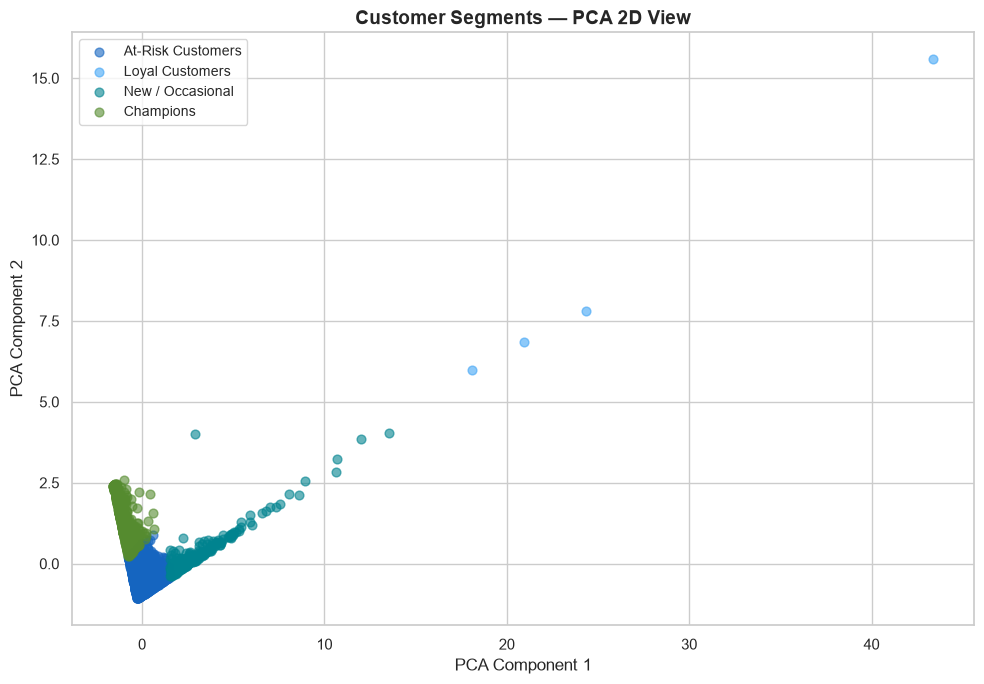

✅ Saved: reports/cluster_pca.png


In [41]:
# Visualize clusters using PCA (reduce to 2D for plotting)
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(rfm_scaled)

rfm['PCA1'] = coords[:, 0]
rfm['PCA2'] = coords[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
colors  = ['#1565C0', '#42A5F5', '#00838F', '#558B2F']

for cluster_id, label in cluster_labels.items():
    mask = rfm['Cluster'] == cluster_id
    ax.scatter(
        rfm.loc[mask, 'PCA1'],
        rfm.loc[mask, 'PCA2'],
        label=label, alpha=0.6,
        color=colors[cluster_id], s=40
    )

ax.set_title('Customer Segments — PCA 2D View', fontsize=14, fontweight='bold')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../reports/cluster_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: reports/cluster_pca.png')

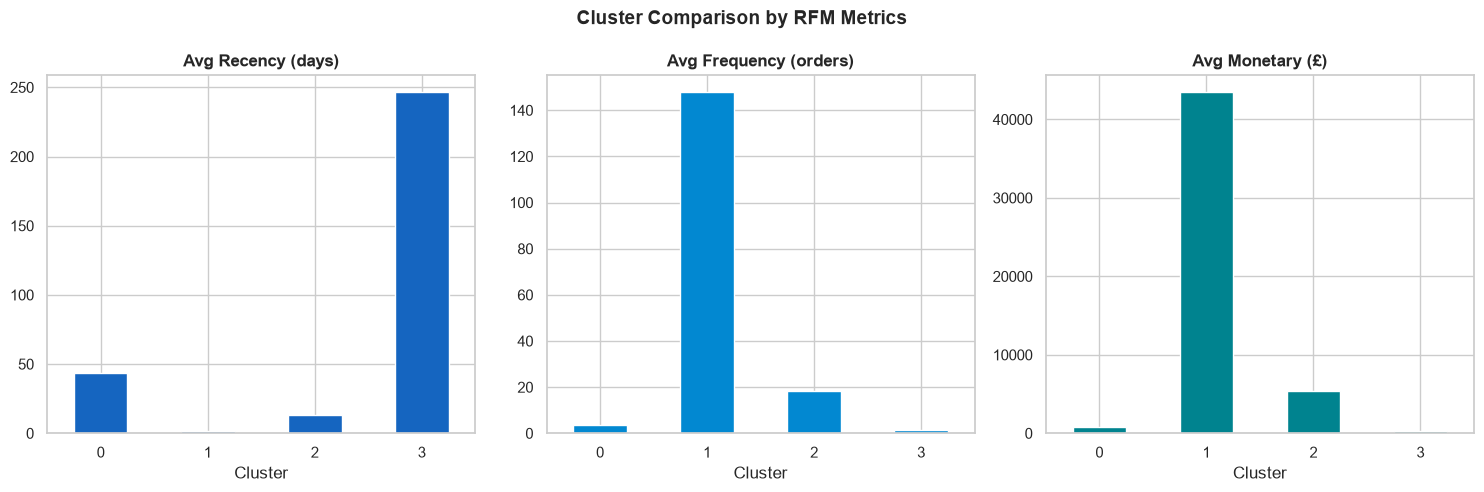

✅ Saved: reports/cluster_comparison.png


In [42]:
# Cluster comparison bar charts
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary']
titles  = ['Avg Recency (days)', 'Avg Frequency (orders)', 'Avg Monetary (£)']
colors  = ['#1565C0', '#0288D1', '#00838F']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    cluster_profile[metric].plot(kind='bar', ax=ax, color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Cluster Comparison by RFM Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/cluster_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: reports/cluster_comparison.png')

In [43]:
# Segment recommendations
print('=' * 60)
print('       📌 SEGMENT RECOMMENDATIONS')
print('=' * 60)
recommendations = {
    'Champions':         'Reward them — loyalty discounts, early access to new products',
    'Loyal Customers':   'Upsell premium products — they trust the brand',
    'At-Risk Customers': 'Win-back campaigns — special offers to re-engage',
    'New / Occasional':  'Nurture with onboarding emails and first-purchase discounts'
}
for seg, rec in recommendations.items():
    print(f'\n  {seg}:')
    print(f'    → {rec}')
print('=' * 60)

       📌 SEGMENT RECOMMENDATIONS

  Champions:
    → Reward them — loyalty discounts, early access to new products

  Loyal Customers:
    → Upsell premium products — they trust the brand

  At-Risk Customers:
    → Win-back campaigns — special offers to re-engage

  New / Occasional:
    → Nurture with onboarding emails and first-purchase discounts


---
# 📅 DAY 25–26: BASIC PREDICTIVE MODEL

## Part A — Linear Regression (Predict Revenue)

In [44]:
# Prepare features for regression
reg_df = df[['Quantity', 'UnitPrice', 'TotalPrice']].dropna()

X = reg_df[['Quantity', 'UnitPrice']]
y = reg_df['TotalPrice']

# Split into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'✅ Train size : {len(X_train):,}')
print(f'✅ Test size  : {len(X_test):,}')

✅ Train size : 266,587
✅ Test size  : 66,647


In [45]:
# Train Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('=' * 55)
print('   LINEAR REGRESSION — Predict Total Price')
print('=' * 55)
print(f'  R² Score  : {r2:.4f}  (higher = better, max 1.0)')
print(f'  MAE       : £{mae:.2f}  (avg prediction error)')
print(f'  RMSE      : £{rmse:.2f} (penalizes large errors more)')
print(f'\n  Coefficients:')
for feat, coef in zip(X.columns, lr.coef_):
    print(f'    {feat}: {coef:.4f}')
print(f'  Intercept : {lr.intercept_:.4f}')
print('=' * 55)

   LINEAR REGRESSION — Predict Total Price
  R² Score  : 0.5899  (higher = better, max 1.0)
  MAE       : £5.18  (avg prediction error)
  RMSE      : £8.33 (penalizes large errors more)

  Coefficients:
    Quantity: 1.4215
    UnitPrice: 5.2533
  Intercept : -9.3459


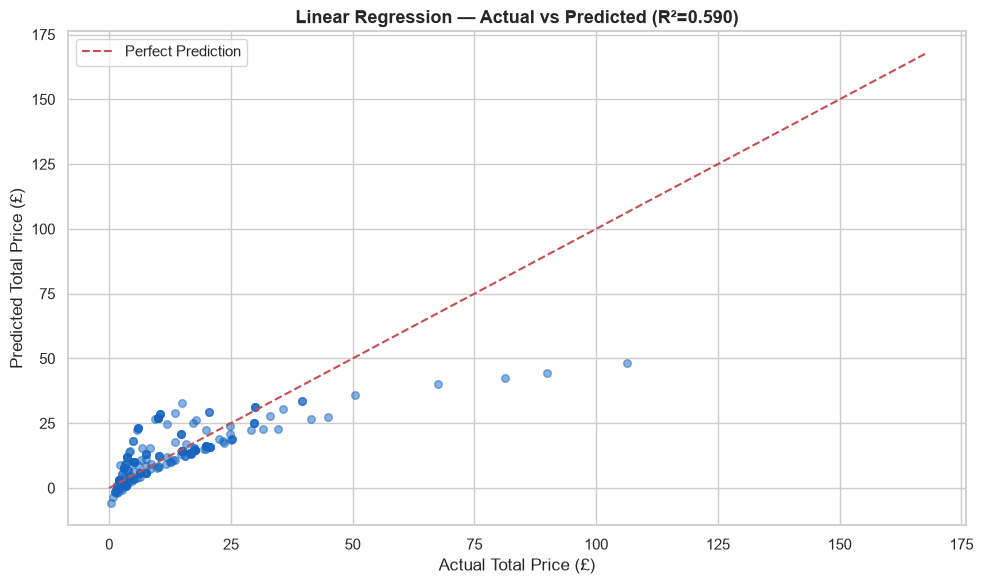

✅ Saved: reports/model_linear_regression.png


In [46]:
# Actual vs Predicted plot
sample_idx = np.random.choice(len(y_test), 200, replace=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    y_test.values[sample_idx],
    y_pred[sample_idx],
    alpha=0.5, color='#1565C0', s=30
)
max_val = max(y_test.max(), y_pred.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
ax.set_title(f'Linear Regression — Actual vs Predicted (R²={r2:.3f})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Actual Total Price (£)')
ax.set_ylabel('Predicted Total Price (£)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/model_linear_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: reports/model_linear_regression.png')

## Part B — Logistic Regression (Predict High-Value Order)

In [47]:
# Target: Is this a high-value order? (1 = yes, 0 = no)
df['HighValue'] = (df['TotalPrice'] > df['TotalPrice'].median()).astype(int)

clf_df = df[['Quantity', 'UnitPrice', 'Month', 'HighValue']].dropna()

X_clf = clf_df[['Quantity', 'UnitPrice', 'Month']]
y_clf = clf_df['HighValue']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

# Scale features
scaler_clf = StandardScaler()
X_tr_sc    = scaler_clf.fit_transform(X_tr)
X_te_sc    = scaler_clf.transform(X_te)

# Train model
log_reg = LogisticRegression(random_state=42, max_iter=500)
log_reg.fit(X_tr_sc, y_tr)

y_pred_clf = log_reg.predict(X_te_sc)

acc  = accuracy_score(y_te, y_pred_clf)
prec = precision_score(y_te, y_pred_clf)
rec  = recall_score(y_te, y_pred_clf)

print('=' * 55)
print('   LOGISTIC REGRESSION — Predict High-Value Order')
print('=' * 55)
print(f'  Accuracy  : {acc*100:.2f}%  (overall correct predictions)')
print(f'  Precision : {prec*100:.2f}%  (of predicted high-value, how many were right)')
print(f'  Recall    : {rec*100:.2f}%  (of actual high-value, how many we caught)')
print('\n  Classification Report:')
print(classification_report(y_te, y_pred_clf, target_names=['Low Value', 'High Value']))
print('=' * 55)

   LOGISTIC REGRESSION — Predict High-Value Order
  Accuracy  : 87.22%  (overall correct predictions)
  Precision : 84.80%  (of predicted high-value, how many were right)
  Recall    : 90.60%  (of actual high-value, how many we caught)

  Classification Report:
              precision    recall  f1-score   support

   Low Value       0.90      0.84      0.87     33425
  High Value       0.85      0.91      0.88     33222

    accuracy                           0.87     66647
   macro avg       0.87      0.87      0.87     66647
weighted avg       0.87      0.87      0.87     66647



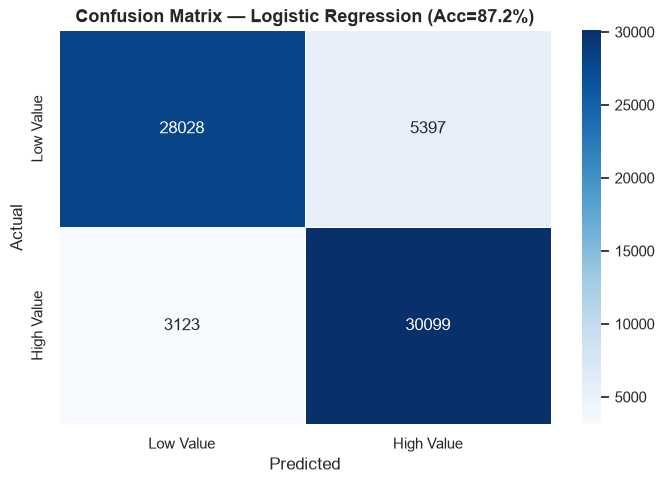

✅ Saved: reports/model_confusion_matrix.png


In [48]:
# Confusion Matrix
cm = confusion_matrix(y_te, y_pred_clf)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues', linewidths=0.5,
    xticklabels=['Low Value', 'High Value'],
    yticklabels=['Low Value', 'High Value'],
    ax=ax
)
ax.set_title(f'Confusion Matrix — Logistic Regression (Acc={acc*100:.1f}%)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('../reports/model_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: reports/model_confusion_matrix.png')

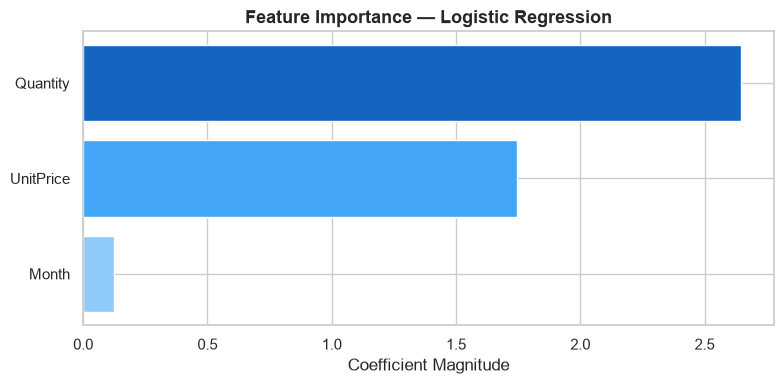

✅ Saved: reports/model_feature_importance.png


In [49]:
# Feature Importance
feature_names = ['Quantity', 'UnitPrice', 'Month']
coefficients  = abs(log_reg.coef_[0])
feat_imp      = pd.DataFrame({'Feature': feature_names, 'Importance': coefficients})
feat_imp      = feat_imp.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(feat_imp['Feature'], feat_imp['Importance'],
        color=['#90CAF9', '#42A5F5', '#1565C0'])
ax.set_title('Feature Importance — Logistic Regression',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Magnitude')
plt.tight_layout()
plt.savefig('../reports/model_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: reports/model_feature_importance.png')

---
## 💡 Statistical & Model Findings Summary

In [50]:
print('=' * 65)
print('         📌 KEY FINDINGS — TASK 4 SUMMARY')
print('=' * 65)
print(f"""
1️⃣  DESCRIPTIVE STATS:
   Average order value : £{df['TotalPrice'].mean():.2f}
   Median order value  : £{df['TotalPrice'].median():.2f}
   Data is right-skewed — most orders are small but a few
   very large orders pull the mean up.

2️⃣  T-TEST (UK vs Non-UK):
   P-value = {p_value:.4f} → {'Significant difference found' if p_value < 0.05 else 'No significant difference'}
   UK avg: £{uk.mean():.2f} | Non-UK avg: £{non_uk.mean():.2f}

3️⃣  CHI-SQUARE TEST (Month vs High-Value):
   P-value = {p:.6f} → {'Month significantly affects order value' if p < 0.05 else 'No significant relationship'}

4️⃣  CUSTOMER SEGMENTATION (K-Means, K=4):
   Champions        → Reward with loyalty programs
   Loyal Customers  → Upsell premium products
   At-Risk          → Win-back campaigns needed
   Occasional       → Nurture with targeted offers

5️⃣  PREDICTIVE MODELS:
   Linear Regression  → R² = {r2:.3f} (predicting order value)
   Logistic Regression → Accuracy = {acc*100:.1f}% (predicting high-value orders)
   Top feature: UnitPrice is the strongest predictor
""")
print('=' * 65)

         📌 KEY FINDINGS — TASK 4 SUMMARY

1️⃣  DESCRIPTIVE STATS:
   Average order value : £12.90
   Median order value  : £10.14
   Data is right-skewed — most orders are small but a few
   very large orders pull the mean up.

2️⃣  T-TEST (UK vs Non-UK):
   P-value = 0.0000 → Significant difference found
   UK avg: £12.26 | Non-UK avg: £18.77

3️⃣  CHI-SQUARE TEST (Month vs High-Value):
   P-value = 0.000000 → Month significantly affects order value

4️⃣  CUSTOMER SEGMENTATION (K-Means, K=4):
   Champions        → Reward with loyalty programs
   Loyal Customers  → Upsell premium products
   At-Risk          → Win-back campaigns needed
   Occasional       → Nurture with targeted offers

5️⃣  PREDICTIVE MODELS:
   Linear Regression  → R² = 0.590 (predicting order value)
   Logistic Regression → Accuracy = 87.2% (predicting high-value orders)
   Top feature: UnitPrice is the strongest predictor



---
## ✅ Task 4 Complete!

**What we accomplished:**
- ✅ Descriptive statistics — mean, median, std, skewness, kurtosis
- ✅ Hypothesis testing — T-Test (UK vs Non-UK), Chi-Square (Month vs High-Value)
- ✅ Confidence Intervals — 95% CI for average order value
- ✅ RFM feature engineering — Recency, Frequency, Monetary per customer
- ✅ K-Means Clustering — 4 customer segments with PCA 2D visualization
- ✅ Segment profiling — business recommendations per cluster
- ✅ Linear Regression — predict total order value (R², MAE, RMSE)
- ✅ Logistic Regression — predict high-value orders (Accuracy, Precision, Recall)
- ✅ Confusion matrix and feature importance charts

**Next Steps:**
1. Push this notebook to GitHub
2. Record a screen recording
3. Post on LinkedIn and submit on ApexPlanet portal
4. Move to **Task 5 — Final Report, Automation & Presentation** 🚀

---
*ApexPlanet Data Analytics Internship — Task 4 of 5*